# 1. Import datasheet và chuẩn bị tệp dữ liệu

Source code được thực hiện trên môi trường Kaggle Notebook.
File notebook được tải trực tiếp từ Kaggle dưới định dạng .ipynb.

Dữ liệu được cung cấp qua link https://drive.google.com/drive/folders/1v_Uvr3oV8XpzS7s_nh1j1M8b3ANea4R7
Nếu cần chạy lại trên máy cá nhân, cần điều chỉnh lại đường dẫn dữ liệu cho phù hợp.

In [7]:
import pandas as pd      
import numpy as np        
import matplotlib.pyplot as plt    
import seaborn as sns                
import os
import gc                                

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

In [9]:
print(os.listdir("/kaggle/input"))

['cicds2017-data-sheet']


In [10]:
print(os.listdir("/kaggle/input/cicds2017-data-sheet/TrafficLabelling"))

['Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [11]:
base_path = "/kaggle/input/cicds2017-data-sheet/TrafficLabelling"

In [12]:
# ĐỌC FILE CSV
df_Monday = pd.read_csv(os.path.join(base_path, "Monday-WorkingHours.pcap_ISCX.csv"), encoding="latin1", low_memory=False)
df_Tuesday = pd.read_csv(os.path.join(base_path, "Tuesday-WorkingHours.pcap_ISCX.csv"), encoding="latin1", low_memory=False)
df_Wednesday = pd.read_csv(os.path.join(base_path, "Wednesday-workingHours.pcap_ISCX.csv"), encoding="latin1", low_memory=False)
df_Thursday_Web = pd.read_csv(os.path.join(base_path, "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"), encoding="latin1", low_memory=False)
df_Thursday_Infiltration = pd.read_csv(os.path.join(base_path, "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv"), encoding="latin1", low_memory=False)
df_Friday_Morning = pd.read_csv(os.path.join(base_path, "Friday-WorkingHours-Morning.pcap_ISCX.csv"), encoding="latin1", low_memory=False)
df_Friday_DDoS = pd.read_csv(os.path.join(base_path, "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"), encoding="latin1", low_memory=False)
df_Friday_PortScan = pd.read_csv(os.path.join(base_path, "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"), encoding="latin1", low_memory=False)

print("Load dữ liệu hoàn tất!")
print("df_Monday shape:", df_Monday.shape)
print("df_Tuesday shape:", df_Tuesday.shape)
print("df_Wednesday shape:", df_Wednesday.shape)
print("df_Thursday_Web shape:", df_Thursday_Web.shape)
print("df_Thursday_Infiltration shape:", df_Thursday_Infiltration.shape)
print("df_Friday_Morning shape:", df_Friday_Morning.shape)
print("df_Friday_DDoS shape:", df_Friday_DDoS.shape)
print("df_Friday_PortScan shape:", df_Friday_PortScan.shape)

Load dữ liệu hoàn tất!
df_Monday shape: (529918, 85)
df_Tuesday shape: (445909, 85)
df_Wednesday shape: (692703, 85)
df_Thursday_Web shape: (458968, 85)
df_Thursday_Infiltration shape: (288602, 85)
df_Friday_Morning shape: (191033, 85)
df_Friday_DDoS shape: (225745, 85)
df_Friday_PortScan shape: (286467, 85)


# 2. Datasheet Preparetion

## 2.1 Gộp các Data

In [13]:
# GỘP TẤT CẢ DF THÀNH 1 DATASET LỚN
# df_data = full CICIDS2017 dataset
data_list = [df_Monday, df_Tuesday, df_Wednesday, df_Thursday_Web, df_Thursday_Infiltration, df_Friday_Morning, df_Friday_DDoS, df_Friday_PortScan]
df_data = pd.concat(data_list)

# In thông tin dataset
print("Gộp dữ liệu thành công!")
print("Shape df_data:", df_data.shape)

Gộp dữ liệu thành công!
Shape df_data: (3119345, 85)


In [14]:
df_data.tail()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
286462,192.168.10.16-199.244.48.55-41926-443-6,192.168.10.16,41926.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,196135.0,49.0,57.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
286463,192.168.10.16-199.244.48.55-41934-443-6,192.168.10.16,41934.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,378424.0,49.0,59.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
286464,192.168.10.16-199.244.48.55-41932-443-6,192.168.10.16,41932.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,161800.0,70.0,103.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
286465,192.168.10.16-199.244.48.55-41930-443-6,192.168.10.16,41930.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,142864.0,50.0,62.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
286466,192.168.10.16-199.244.48.55-41928-443-6,192.168.10.16,41928.0,199.244.48.55,443.0,6.0,7/7/2017 3:29,186928.0,46.0,57.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


### 2.1.1 Thực hiện xóa các datasheet để giảm tải dung lượng sử dụng RAM

In [15]:

del df_Monday, df_Tuesday, df_Wednesday
del df_Thursday_Web, df_Thursday_Infiltration
del df_Friday_Morning, df_Friday_DDoS, df_Friday_PortScan

gc.collect() 

60

In [16]:
print("Kiểm tra cột và loại cột")
df_data.info()

Kiểm tra cột và loại cột
<class 'pandas.core.frame.DataFrame'>
Index: 3119345 entries, 0 to 286466
Data columns (total 85 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Flow ID                       object 
 1    Source IP                    object 
 2    Source Port                  float64
 3    Destination IP               object 
 4    Destination Port             float64
 5    Protocol                     float64
 6    Timestamp                    object 
 7    Flow Duration                float64
 8    Total Fwd Packets            float64
 9    Total Backward Packets       float64
 10  Total Length of Fwd Packets   float64
 11   Total Length of Bwd Packets  float64
 12   Fwd Packet Length Max        float64
 13   Fwd Packet Length Min        float64
 14   Fwd Packet Length Mean       float64
 15   Fwd Packet Length Std        float64
 16  Bwd Packet Length Max         float64
 17   Bwd Packet Length Min        float64
 18   Bw

In [17]:
df_data.select_dtypes(include='object').columns

Index(['Flow ID', ' Source IP', ' Destination IP', ' Timestamp', ' Label'], dtype='object')

In [18]:
print("Xen tên cột:")
print(df_data.columns)

Xen tên cột:
Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Leng

In [19]:
print("Số dòng và số cột của data: ",df_data.shape)

Số dòng và số cột của data:  (3119345, 85)


Trong quá trình kiểm tra dataset CICIDS2017 sau khi gộp các file, nhận thấy:

Nhiều cột có khoảng trắng ở đầu tên cột

In [20]:
print("Xóa khoảng trống cột")
df_data.columns = df_data.columns.str.strip()

Xóa khoảng trống cột


In [21]:
df_data.columns = df_data.columns.str.strip()
print("Cắt khoảng trắng thành công")

Cắt khoảng trắng thành công


In [22]:
pd.options.display.max_rows = 86

print('Tổng quan và các cột:')
df_data.describe().transpose()

Tổng quan và các cột:


,count,mean,std,min,25%,50%,75%,max
Source Port,2830743.0,4.112886e+04,2.229494e+04,0.000000e+00,32774.000000,50944.000000,5.841300e+04,6.553500e+04
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Protocol,2830743.0,9.880341e+00,5.261922e+00,0.000000e+00,6.000000,6.000000,1.700000e+01,1.700000e+01
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-1.300000e+01,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.000000e+00,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.000000e+00,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.000000e+00,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.000000e+00,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.000000e+00,0.000000,2.000000,3.600000e+01,2.325000e+03


## 2.2 Data Cleaning

In [23]:
print("Thực hiện kiểm tra dữ liệu")

#1. Kiểm tra có bao nhiêu giá trị NaN
nan_count = df_data.isna().sum().sum()
print("Tổng số giá trị NaN trong dataset:", nan_count)

#2. Kiểm tra có bao nhiêu giá trị vô cùng (inf, -inf)
inf_count = np.isinf(df_data.select_dtypes(include=[np.number])).sum().sum()
print("Tổng số giá trị vô cùng (inf, -inf):", inf_count)

#3. Kiểm tra số dòng trùng lặp
dup_count = df_data.duplicated().sum()
print("Số dòng bị trùng lặp:", dup_count)

#4. Kiểm tra kiểu dữ liệu của các thuộc tính
print("\nThống kê kiểu dữ liệu trong dataset:")
print(df_data.dtypes.value_counts())

#5. Kiểm tra các cột không phải số
non_numeric_cols = df_data.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nCác cột không phải dạng số:", non_numeric_cols)

print("\nKích thước dataset là:", df_data.shape)
print("\nHoàn thành kiểm tra")

Thực hiện kiểm tra dữ liệu
Tổng số giá trị NaN trong dataset: 24532528
Tổng số giá trị vô cùng (inf, -inf): 4376
Số dòng bị trùng lặp: 288804

Thống kê kiểu dữ liệu trong dataset:
float64    80
object      5
Name: count, dtype: int64

Các cột không phải dạng số: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label']

Kích thước dataset là: (3119345, 85)

Hoàn thành kiểm tra


In [24]:
print(df_data['Label'].value_counts())

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [25]:
print("Kiểm tra có bao nhiêu dữ liệu NaN")
df_data.isna().sum()

Kiểm tra có bao nhiêu dữ liệu NaN


Flow ID                        288602
Source IP                      288602
Source Port                    288602
Destination IP                 288602
Destination Port               288602
Protocol                       288602
Timestamp                      288602
Flow Duration                  288602
Total Fwd Packets              288602
Total Backward Packets         288602
Total Length of Fwd Packets    288602
Total Length of Bwd Packets    288602
Fwd Packet Length Max          288602
Fwd Packet Length Min          288602
Fwd Packet Length Mean         288602
Fwd Packet Length Std          288602
Bwd Packet Length Max          288602
Bwd Packet Length Min          288602
Bwd Packet Length Mean         288602
Bwd Packet Length Std          288602
Flow Bytes/s                   289960
Flow Packets/s                 288602
Flow IAT Mean                  288602
Flow IAT Std                   288602
Flow IAT Max                   288602
Flow IAT Min                   288602
Fwd IAT Tota

Nhìn qua kết quả thấy NaN có vẻ như cột nào cũng có như nào, nên ktr xem để chắc chắn rằng không bị sai xót

In [26]:
df_data[df_data.isna().all(axis=1)].shape

(288602, 85)

Vì các cột đều có NaN cùng một 1 số là 288602 nên cần phải drop NaN, nhưng để đảm báo tính toàn vẹn chắc chắn thì chỉ drop các dòng mà các cột đều báo là NaN

Bước tiếp theo là check xem dữ liệu có bị lặp không

In [27]:
df_data.duplicated().sum()

np.int64(288804)

Vì số lượng dòng bị lặp còn lại 202 dòng sau khi drop NaN, và 202 là một con số không đáng kể so với 2tr dòng do đó nên có thể drop

In [28]:
df_data.drop_duplicates(inplace=True)
df_data.reset_index(drop=True, inplace=True)

print("Shape sau khi drop duplicate:", df_data.shape)

Shape sau khi drop duplicate: (2830541, 85)


In [29]:
print("Số lượng inf trong dataset:", 
      np.isinf(df_data.select_dtypes(include=[np.number])).sum().sum())

Số lượng inf trong dataset: 4369


In [30]:
# 1. Chuyển các inf và -inf thành NaN
df_data.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Xóa các dòng chứa NaN (tức là các dòng từng có inf)
df_data.dropna(inplace=True)

# 3. Reset index
df_data.reset_index(drop=True, inplace=True)

print("Đã xóa các giá trị inf")
print("Shape mới:", df_data.shape)

Đã xóa các giá trị inf
Shape mới: (2827677, 85)


In [31]:
print("Tổng NaN sau clean:", df_data.isna().sum().sum())

Tổng NaN sau clean: 0


In [32]:
print("Thực hiện kiểm tra dữ liệu sau khi clean")

# 1. Kiểm tra giá trị NaN
nan_count = df_data.isna().sum().sum()
print("Tổng số giá trị NaN trong dataset:", nan_count)

# 2. Kiểm tra giá trị vô cùng (inf, -inf)
inf_count = np.isinf(df_data.select_dtypes(include=[np.number])).sum().sum()
print("Tổng số giá trị vô cùng (inf, -inf):", inf_count)

# 3. Kiểm tra dòng trùng lặp
dup_count = df_data.duplicated().sum()
print("Số dòng bị trùng lặp:", dup_count)

# 4. Kiểm tra kiểu dữ liệu
print("\nThống kê kiểu dữ liệu trong dataset:")
print(df_data.dtypes.value_counts())

# 5. Kiểm tra các cột không phải số
non_numeric_cols = df_data.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nCác cột không phải dạng số:", non_numeric_cols)

# 6. Kiểm tra kích thước dataset
print("\nKích thước dataset (rows, columns):", df_data.shape)

Thực hiện kiểm tra dữ liệu sau khi clean
Tổng số giá trị NaN trong dataset: 0
Tổng số giá trị vô cùng (inf, -inf): 0
Số dòng bị trùng lặp: 0

Thống kê kiểu dữ liệu trong dataset:
float64    80
object      5
Name: count, dtype: int64

Các cột không phải dạng số: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label']

Kích thước dataset (rows, columns): (2827677, 85)


## 2.3 Xóa các cột là metadata

In [33]:
df_data['Source Port']

df_data['Source Port'].unique()

df_data['Source Port'].value_counts()

Source Port
443.0      280580
80.0       122633
123.0       23879
137.0        7771
22.0         5083
            ...  
13737.0         1
29836.0         1
32416.0         1
648.0           1
873.0           1
Name: count, Length: 64638, dtype: int64

In [34]:
df_data['Timestamp']

df_data['Timestamp'].unique()

df_data['Timestamp'].value_counts()

Timestamp
7/7/2017 2:55          46127
7/7/2017 2:52          44052
7/7/2017 2:54          35950
5/7/2017 10:43         18300
5/7/2017 10:44         17573
                       ...  
03/07/2017 09:01:26        1
03/07/2017 08:59:04        1
03/07/2017 08:58:34        1
03/07/2017 01:11:20        1
03/07/2017 03:47:26        1
Name: count, Length: 27964, dtype: int64

In [35]:
drop_cols = [
    'Flow ID',
    'Source IP',
    'Destination IP',
    'Destination Port',
    'Source Port',
    'Timestamp'
]

df_data.drop(columns=drop_cols, inplace=True, errors='ignore')

print("Shape sau khi drop metadata:", df_data.shape)

Shape sau khi drop metadata: (2827677, 79)


/tmp/ipykernel_57/1058075706.py:31: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


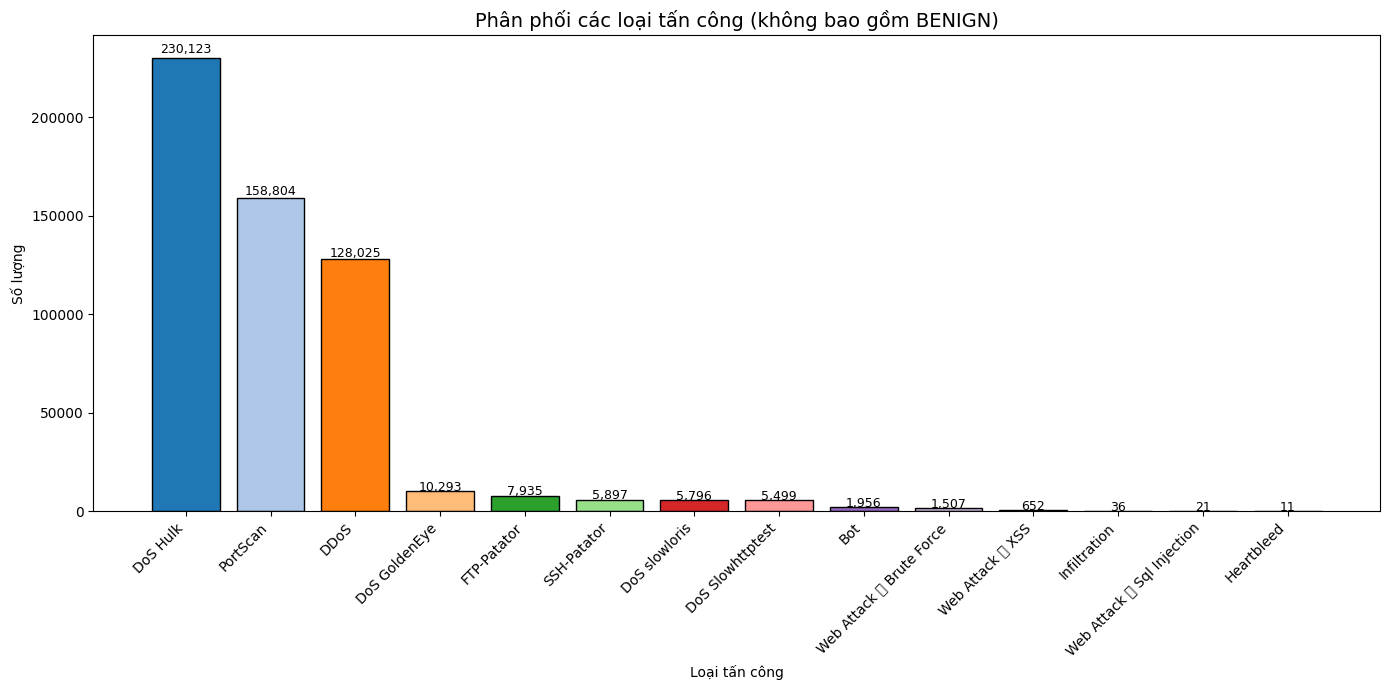

In [36]:
# Bỏ BENIGN
attack_counts = df_data['Label'].value_counts().drop('BENIGN')

colors = plt.cm.tab20.colors[:len(attack_counts)]

plt.figure(figsize=(14,7))

bars = plt.bar(
    attack_counts.index,
    attack_counts.values,
    color=colors,
    edgecolor='black'
)

plt.title('Phân phối các loại tấn công (không bao gồm BENIGN)', fontsize=14)
plt.xlabel('Loại tấn công')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')

# Hiển thị số trên đầu cột
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + y*0.01,
        f'{int(y):,}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [37]:
print(df_data['Label'].value_counts())

Label
BENIGN                        2271122
DoS Hulk                       230123
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


# 3. Xử lý dữ liệu

## 3.1 Kiểm tra các cột có std=0 và xóa

In [38]:
print("\nKiểm tra các cột có = 0:")
std = df_data.select_dtypes(include='number').std()
zero_std_cols = std[std == 0].index.tolist()
print(f"Số cột std = 0: {len(zero_std_cols)}")
print(zero_std_cols)

if zero_std_cols:
    df_data.drop(columns=zero_std_cols, inplace=True)
    print(f"\nĐã drop {len(zero_std_cols)} cột std = 0")
    print(f"Shape sau khi drop std=0: {df_data.shape}")


Kiểm tra các cột có = 0:
Số cột std = 0: 8
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Đã drop 8 cột std = 0
Shape sau khi drop std=0: (2827677, 71)


## 3.2 Kiểm tra độ tương quan của các đặt trưng


 Vẽ hình ma trận tương quan:


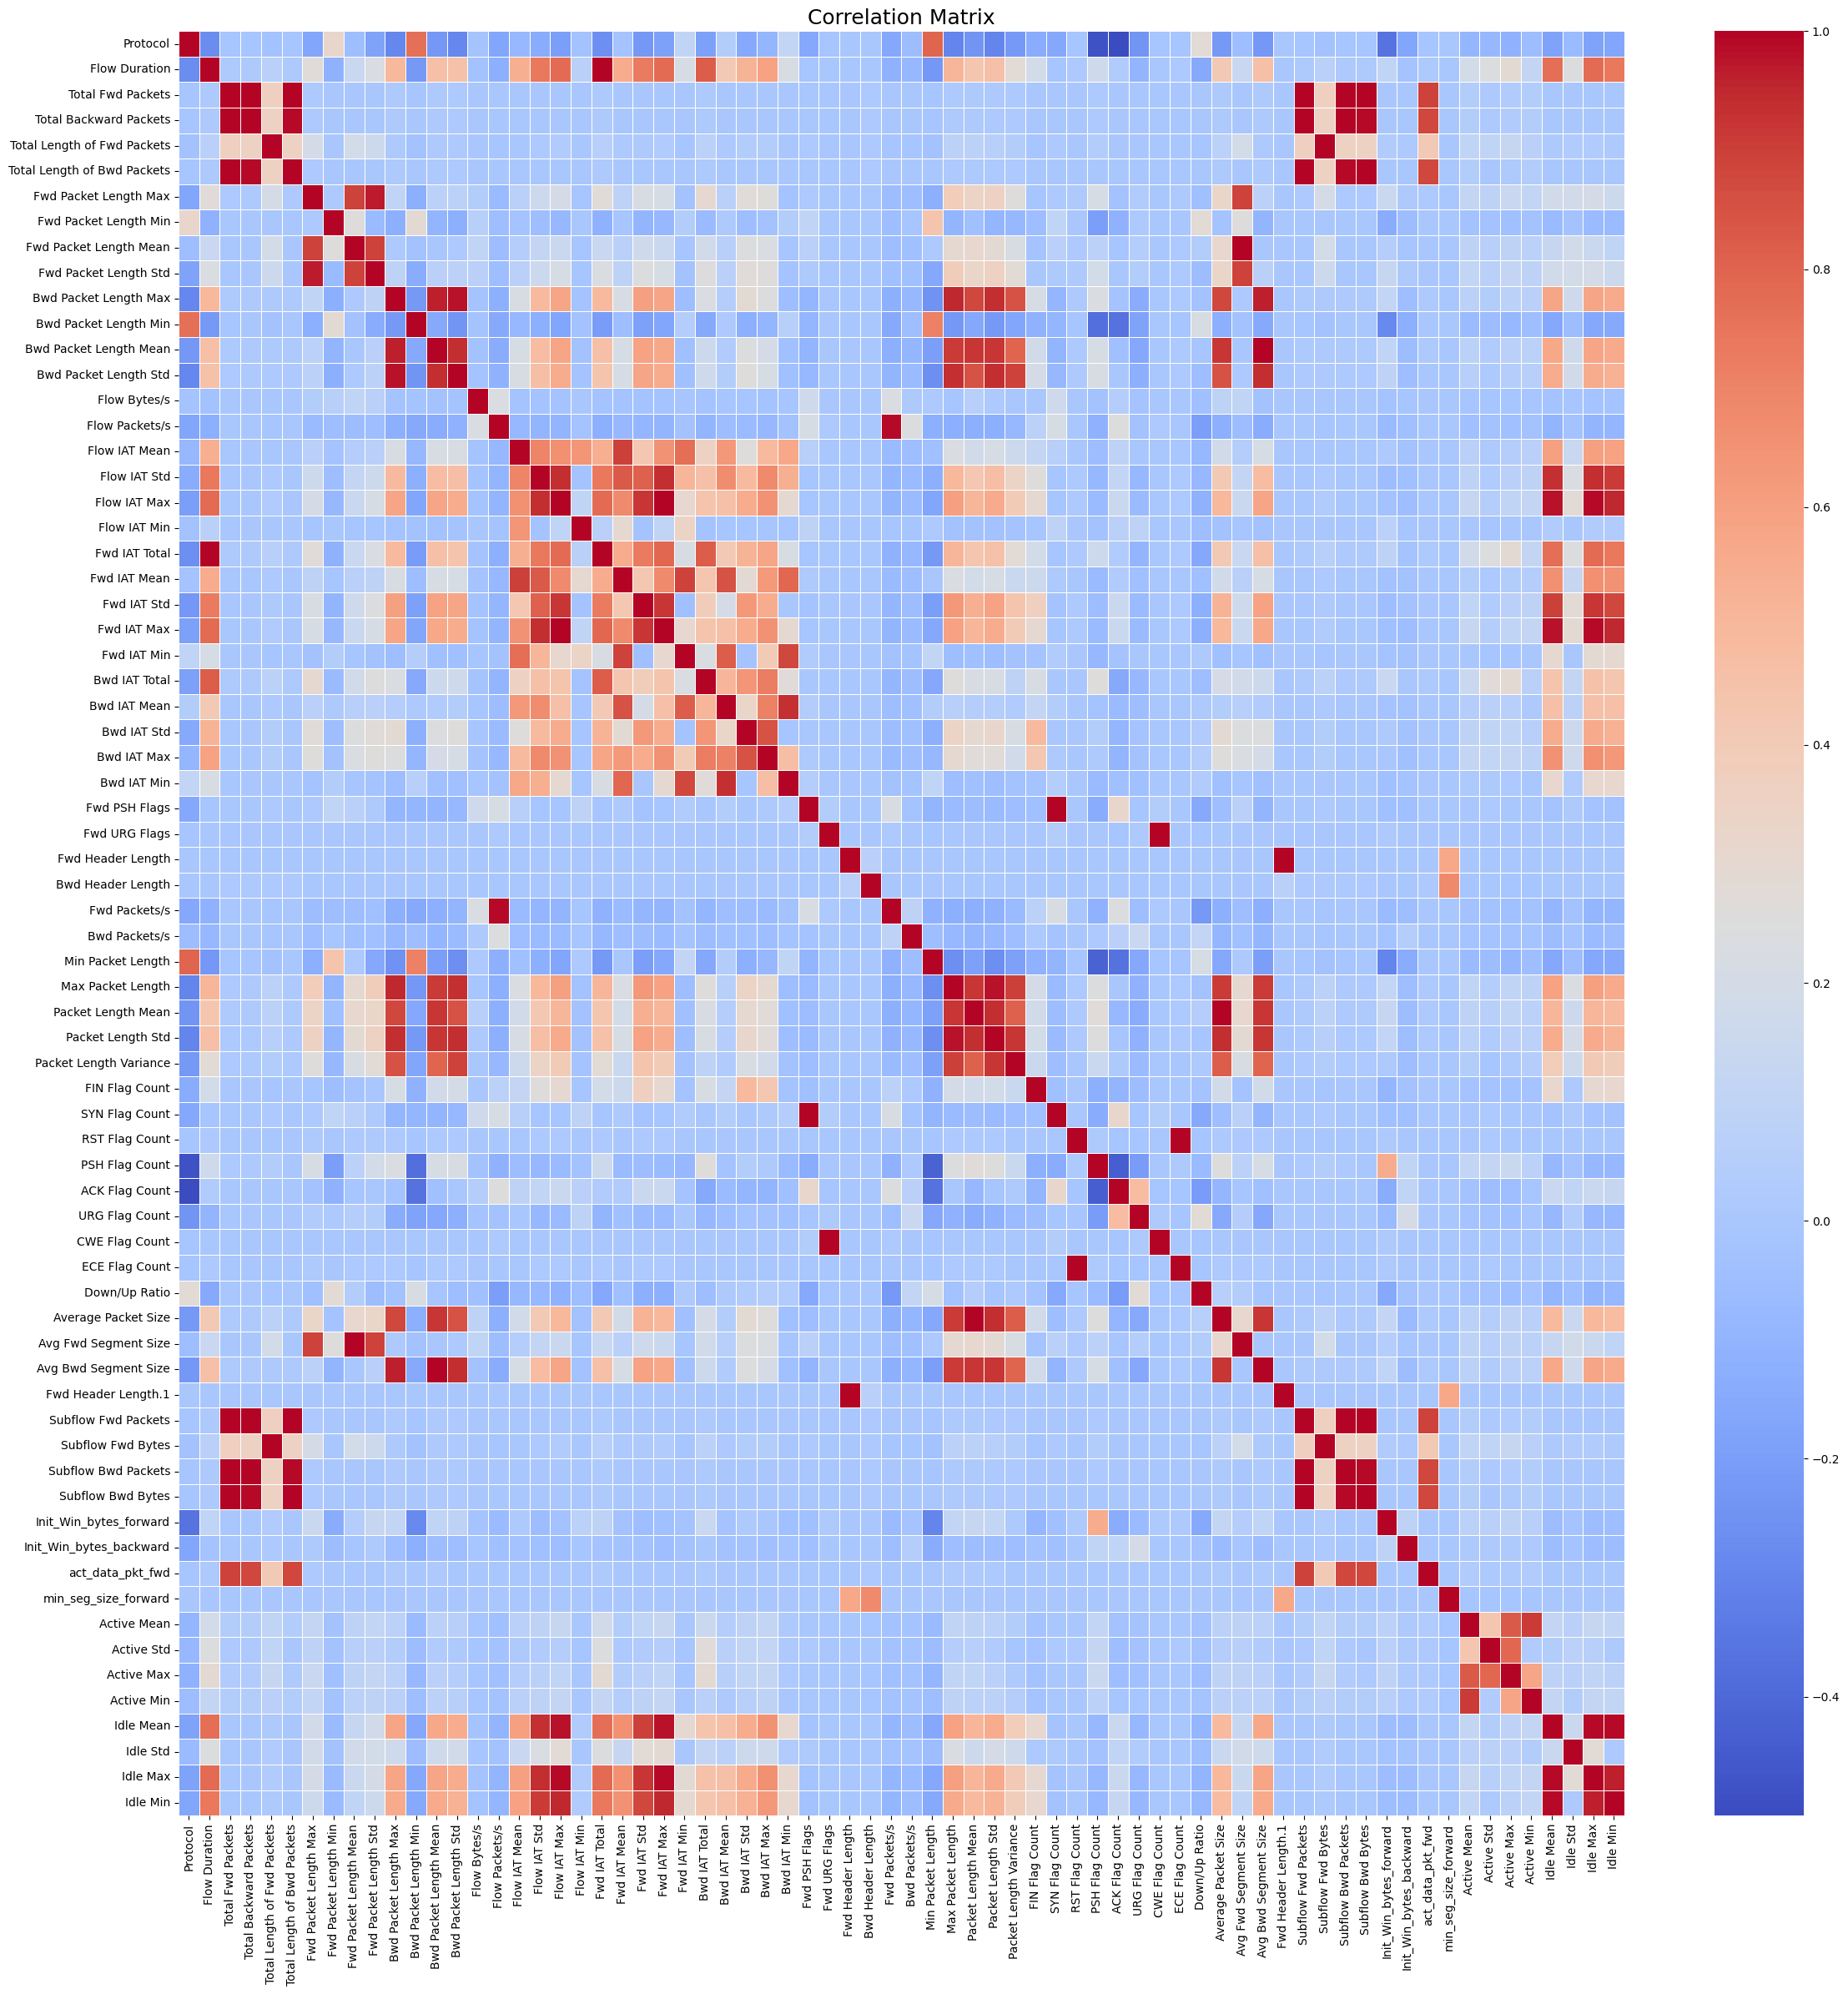

In [39]:
print("\n Vẽ hình ma trận tương quan:")
corr = df_data.select_dtypes(include='number').corr().round(2)

plt.figure(figsize=(24, 24))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidth=0.5)
plt.title('Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.show()

In [40]:
#Drop cột tương quan >= 0.95
print("\nShow các cột có độ tương quan cao (>= 0.90):")
upper = corr.abs().where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
high_corr_cols = [col for col in upper.columns if any(upper[col] >= 0.90)]

print(f"Số cột tương quan >= 0.90: {len(high_corr_cols)}")
print(high_corr_cols)

df_data.drop(columns=high_corr_cols, inplace=True, errors='ignore')

print(f"\nShape sau khi drop: {df_data.shape}")
print(f"Số cột còn lại: {df_data.shape[1]}")



Show các cột có độ tương quan cao (>= 0.90):
Số cột tương quan >= 0.90: 31
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Min', 'Fwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']

Shape sau khi drop: (2827677, 40)
Số cột còn lại: 40



 Vẽ hình ma trận tương quan:


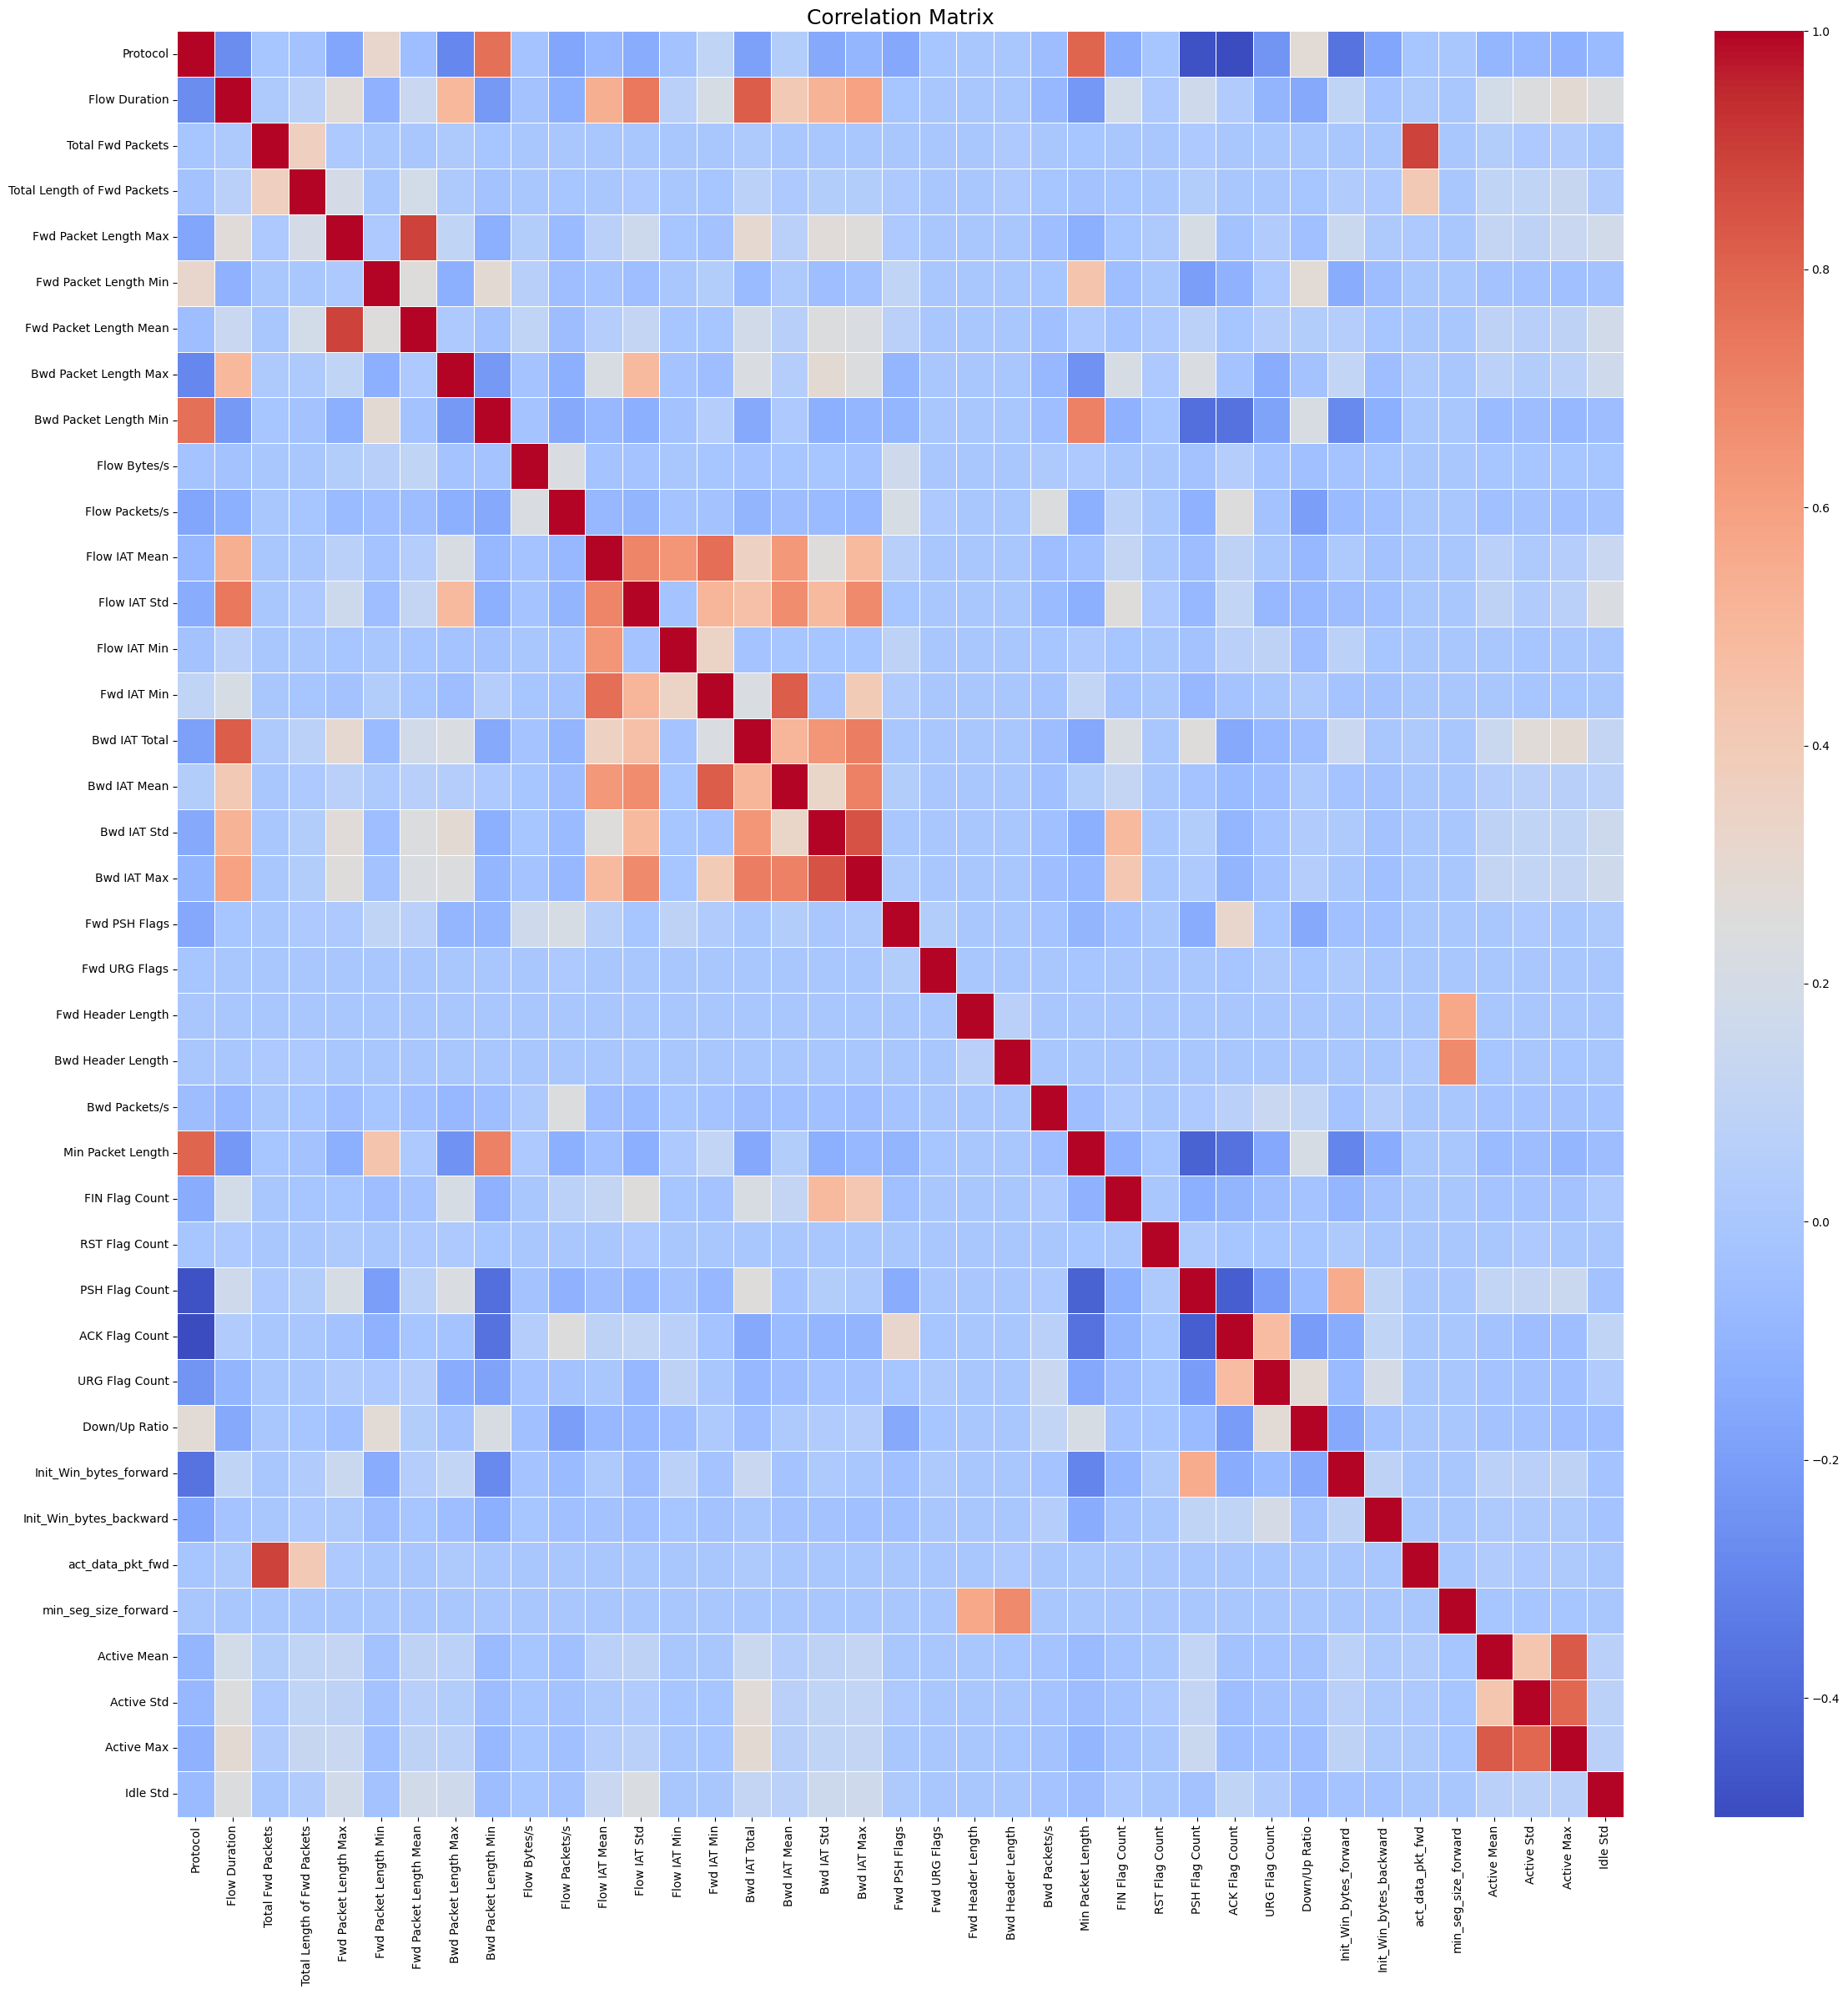

In [41]:
print("\n Vẽ hình ma trận tương quan:")
corr = df_data.select_dtypes(include='number').corr().round(2)

plt.figure(figsize=(24, 24))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidth=0.5)
plt.title('Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.show()

## 3.3 Xử lý nhãn và phân phối lại

In [42]:
print(df_data['Label'].value_counts())

Label
BENIGN                        2271122
DoS Hulk                       230123
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


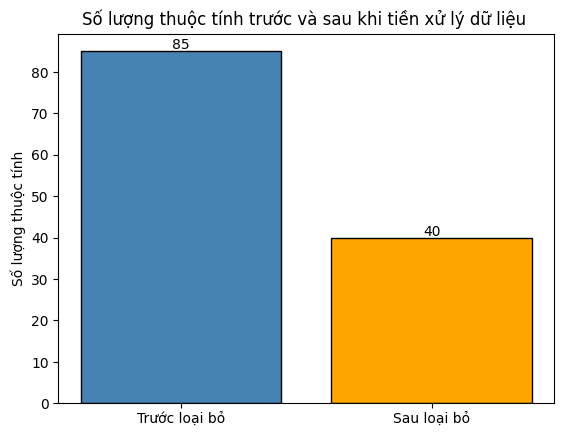

In [43]:
import matplotlib.pyplot as plt

labels = ['Trước loại bỏ', 'Sau loại bỏ']
values = [85, 40]

bars = plt.bar(
    labels,
    values,
    color=['steelblue','orange'],
    edgecolor='black'
)

plt.title('Số lượng thuộc tính trước và sau khi tiền xử lý dữ liệu ')
plt.ylabel('Số lượng thuộc tính')

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.5,
        int(y),
        ha='center'
    )

plt.show()

In [44]:
def map_attack(label):
    label = label.strip()
    
    if label == 'BENIGN':
        return 'BENIGN'
    
    elif label in ['DoS Hulk', 'DoS GoldenEye', 
                   'DoS slowloris', 'DoS Slowhttptest']:
        return 'DoS'
    
    elif label == 'DDoS':
        return 'DDoS'
    
    elif label in ['FTP-Patator', 'SSH-Patator']:
        return 'BruteForce'
    
    elif 'Brute Force' in label:
        return 'BruteForce'
    
    elif label == 'PortScan':
        return 'PortScan'
    
    elif label == 'Bot':
        return 'Bot'
    
    elif 'XSS' in label or 'Sql Injection' in label:
        return 'WebAttack'
    
    elif label == 'Infiltration':
        return 'Infiltration'

    elif label == 'Heartbleed':
        return 'Heartbleed'
    else:
        return 'Unknown'

In [45]:
df_data['Label'] = df_data['Label'].apply(map_attack)

print(df_data['Label'].value_counts())

Label
BENIGN          2271122
DoS              251711
PortScan         158804
DDoS             128025
BruteForce        15339
Bot                1956
WebAttack           673
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


In [46]:
from imblearn.over_sampling import SMOTE
import pandas as pd 

In [47]:
# Cell 1: Undersample BENIGN + Drop
df_data_clean = df_data[~df_data['Label'].isin(['Infiltration', 'Heartbleed'])]
df_data_clean = df_data_clean[df_data_clean['Label'] != 'Unknown']

df_benign = df_data_clean[df_data_clean['Label'] == 'BENIGN'].sample(
    n=500000, random_state=42
)
df_attacks = df_data_clean[df_data_clean['Label'] != 'BENIGN']

df_temp = pd.concat([df_benign, df_attacks])
df_temp = df_temp.sample(frac=1, random_state=42)
df_temp.reset_index(drop=True, inplace=True)

print("Phân phối sau Undersample:")
print(df_temp['Label'].value_counts())

Phân phối sau Undersample:
Label
BENIGN        500000
DoS           251711
PortScan      158804
DDoS          128025
BruteForce     15339
Bot             1956
WebAttack        673
Name: count, dtype: int64


## 4.1 Chia tập train

In [48]:
# Cell 2: Chia Train/Test TRƯỚC
X = df_temp.drop(columns=['Label'])
y = df_temp['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train set trước SMOTE:")
print(y_train.value_counts())
print(f"\nTổng train: {len(X_train):,}")
print("\nTest set:")
print(y_test.value_counts())
print(f"\nTổng test: {len(X_test):,}")

Train set trước SMOTE:
Label
BENIGN        350000
DoS           176198
PortScan      111163
DDoS           89617
BruteForce     10737
Bot             1369
WebAttack        471
Name: count, dtype: int64

Tổng train: 739,555

Test set:
Label
BENIGN        150000
DoS            75513
PortScan       47641
DDoS           38408
BruteForce      4602
Bot              587
WebAttack        202
Name: count, dtype: int64

Tổng test: 316,953


In [49]:
# Cell 3: SMOTE chỉ trên Train (~3x mẫu thật)
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={
        'Bot':        10000,
        'BruteForce': 30000,
        'WebAttack':  5000
    },
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
y_train_res = pd.Series(y_train_res)

print("Train set sau SMOTE:")
print(y_train_res.value_counts())
print(f"\nTổng train: {len(X_train_res):,}")
print("\nTest set (không đổi):")
print(y_test.value_counts())

Train set sau SMOTE:
Label
BENIGN        350000
DoS           176198
PortScan      111163
DDoS           89617
BruteForce     30000
Bot            10000
WebAttack       5000
Name: count, dtype: int64

Tổng train: 771,978

Test set (không đổi):
Label
BENIGN        150000
DoS            75513
PortScan       47641
DDoS           38408
BruteForce      4602
Bot              587
WebAttack        202
Name: count, dtype: int64


In [50]:
# Cell 4: Tạo biến Multiclass và Binary
X_train_m = X_train_res
y_train_m = y_train_res
X_test_m  = X_test
y_test_m  = y_test

X_train_b = X_train_res
y_train_b = y_train_res.apply(lambda x: 0 if x == 'BENIGN' else 1)
X_test_b  = X_test
y_test_b  = y_test.apply(lambda x: 0 if x == 'BENIGN' else 1)

print("Multiclass train:", y_train_m.value_counts().to_dict())
print("\nBinary train:", y_train_b.value_counts().to_dict())
print("\nSẵn sàng train model!")

Multiclass train: {'BENIGN': 350000, 'DoS': 176198, 'PortScan': 111163, 'DDoS': 89617, 'BruteForce': 30000, 'Bot': 10000, 'WebAttack': 5000}

Binary train: {1: 421978, 0: 350000}

Sẵn sàng train model!


# 4. Huấn luyện mô hình

In [51]:
print(df_temp.shape)

(1056508, 40)


## 4.2 Decision Tree

In [52]:
#  Decision Tree - cả 2 trường hợp
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 60)
print("KẾT QUẢ DECISION TREE (MULTICLASS)")
print("=" * 60)

dt_m = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20
)
dt_m.fit(X_train_m, y_train_m)
y_pred_dt_m = dt_m.predict(X_test_m)

print("Accuracy:", accuracy_score(y_test_m, y_pred_dt_m))
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_dt_m, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_dt_m))



KẾT QUẢ DECISION TREE (MULTICLASS)
Accuracy: 0.9942168081702966

Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9968    0.9940    0.9954    150000
         Bot     0.8706    0.9284    0.8986       587
  BruteForce     0.8895    0.9289    0.9088      4602
        DDoS     0.9959    0.9979    0.9969     38408
         DoS     0.9967    0.9948    0.9958     75513
    PortScan     0.9986    0.9989    0.9987     47641
   WebAttack     0.3739    0.8069    0.5110       202

    accuracy                         0.9942    316953
   macro avg     0.8746    0.9500    0.9007    316953
weighted avg     0.9948    0.9942    0.9944    316953


Confusion Matrix:
[[149099     81    376    154    222     68      0]
 [    42    545      0      0      0      0      0]
 [    54      0   4275      0      0      0    273]
 [    71      0      0  38327     10      0      0]
 [   259      0    126      4  75124      0      0]
 [    33      0      7      0     14

In [53]:
print("\n" + "=" * 60)
print("KẾT QUẢ DECISION TREE (BINARY)")
print("=" * 60)

dt_b = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20
)
dt_b.fit(X_train_b, y_train_b)
y_pred_dt_b = dt_b.predict(X_test_b)

print("Accuracy:", accuracy_score(y_test_b, y_pred_dt_b))
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_dt_b, digits=4,
                            target_names=['Benign', 'Attack']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_b, y_pred_dt_b))


KẾT QUẢ DECISION TREE (BINARY)
Accuracy: 0.985234403839055

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9973    0.9714    0.9842    150000
      Attack     0.9749    0.9977    0.9861    166953

    accuracy                         0.9852    316953
   macro avg     0.9861    0.9845    0.9852    316953
weighted avg     0.9855    0.9852    0.9852    316953


Confusion Matrix:
[[145710   4290]
 [   390 166563]]


## 4.3 Random Forest

In [54]:
#  Random Forest - cả 2 trường hợp
from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("KẾT QUẢ RANDOM FOREST (MULTICLASS)")
print("=" * 60)

rf_m = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=4
)
rf_m.fit(X_train_m, y_train_m)
y_pred_rf_m = rf_m.predict(X_test_m)

print("Accuracy:", accuracy_score(y_test_m, y_pred_rf_m))
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_rf_m, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_rf_m))



KẾT QUẢ RANDOM FOREST (MULTICLASS)
Accuracy: 0.9981101298930757

Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9993    0.9984    0.9988    150000
         Bot     0.8770    0.9472    0.9107       587
  BruteForce     0.9827    0.9615    0.9720      4602
        DDoS     0.9998    0.9995    0.9997     38408
         DoS     0.9987    0.9995    0.9991     75513
    PortScan     0.9987    0.9998    0.9992     47641
   WebAttack     0.4179    0.5792    0.4855       202

    accuracy                         0.9981    316953
   macro avg     0.8963    0.9265    0.9093    316953
weighted avg     0.9983    0.9981    0.9982    316953


Confusion Matrix:
[[149761     77      1      5     93     61      2]
 [    30    556      0      1      0      0      0]
 [    16      0   4425      0      0      0    161]
 [    17      1      0  38390      0      0      0]
 [    38      0      0      0  75473      2      0]
 [     2      0      2      0      5

In [55]:
print("\n" + "=" * 60)
print("KẾT QUẢ RANDOM FOREST (BINARY)")
print("=" * 60)

rf_b = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=4
)
rf_b.fit(X_train_b, y_train_b)
y_pred_rf_b = rf_b.predict(X_test_b)

print("Accuracy:", accuracy_score(y_test_b, y_pred_rf_b))
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_rf_b, digits=4,
                            target_names=['Benign', 'Attack']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_b, y_pred_rf_b))


KẾT QUẢ RANDOM FOREST (BINARY)
Accuracy: 0.9989020454136733

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9993    0.9983    0.9988    150000
      Attack     0.9985    0.9994    0.9990    166953

    accuracy                         0.9989    316953
   macro avg     0.9989    0.9989    0.9989    316953
weighted avg     0.9989    0.9989    0.9989    316953


Confusion Matrix:
[[149752    248]
 [   100 166853]]


## 4.4 XGBoost

In [56]:
# XGBoost - cả 2 trường hợp
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("KẾT QUẢ XGBOOST (MULTICLASS)")
print("=" * 60)

le = LabelEncoder()
y_train_m_enc = le.fit_transform(y_train_m)
y_test_m_enc = le.transform(y_test_m)

xgb_m = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=4,
    eval_metric='mlogloss'
)
xgb_m.fit(X_train_m, y_train_m_enc)
y_pred_xgb_m = le.inverse_transform(xgb_m.predict(X_test_m))

print("Accuracy:", accuracy_score(y_test_m, y_pred_xgb_m))
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_xgb_m, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_xgb_m))



KẾT QUẢ XGBOOST (MULTICLASS)
Accuracy: 0.9982521067792386

Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9997    0.9986    0.9992    150000
         Bot     0.8788    0.9761    0.9249       587
  BruteForce     0.9873    0.9455    0.9659      4602
        DDoS     0.9999    0.9998    0.9999     38408
         DoS     0.9992    0.9998    0.9995     75513
    PortScan     0.9987    0.9998    0.9992     47641
   WebAttack     0.3776    0.7327    0.4983       202

    accuracy                         0.9983    316953
   macro avg     0.8916    0.9503    0.9124    316953
weighted avg     0.9986    0.9983    0.9984    316953


Confusion Matrix:
[[149796     79      6      4     53     60      2]
 [    14    573      0      0      0      0      0]
 [     7      0   4351      0      2      0    242]
 [     7      0      0  38401      0      0      0]
 [    11      0      0      0  75500      2      0]
 [     2      0      2      0      7  4763

In [57]:
print("\n" + "=" * 60)
print("KẾT QUẢ XGBOOST (BINARY)")
print("=" * 60)

xgb_b = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=4,
    eval_metric='logloss'
)
xgb_b.fit(X_train_b, y_train_b)
y_pred_xgb_b = xgb_b.predict(X_test_b)

print("Accuracy:", accuracy_score(y_test_b, y_pred_xgb_b))
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_xgb_b, digits=4,
                            target_names=['Benign', 'Attack']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_b, y_pred_xgb_b))


KẾT QUẢ XGBOOST (BINARY)
Accuracy: 0.9991102781800456

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9997    0.9985    0.9991    150000
      Attack     0.9986    0.9997    0.9992    166953

    accuracy                         0.9991    316953
   macro avg     0.9991    0.9991    0.9991    316953
weighted avg     0.9991    0.9991    0.9991    316953


Confusion Matrix:
[[149768    232]
 [    50 166903]]


## 4.5 LightGBM

In [58]:
#  LightGBM - cả 2 trường hợp
from lightgbm import LGBMClassifier

print("=" * 60)
print("KẾT QUẢ LIGHTGBM (MULTICLASS)")
print("=" * 60)

lgbm_m = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=31,
    class_weight='balanced',  # ← fix lỗi 'lass_weight'
    verbose=-1
)
lgbm_m.fit(X_train_m, y_train_m)
y_pred_lgbm_m = lgbm_m.predict(X_test_m)

print("Accuracy:", accuracy_score(y_test_m, y_pred_lgbm_m))
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_lgbm_m, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_lgbm_m))



KẾT QUẢ LIGHTGBM (MULTICLASS)
Accuracy: 0.3544184784494862

Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.5784    0.2777    0.3752    150000
         Bot     0.0043    0.4480    0.0085       587
  BruteForce     0.0641    0.2334    0.1005      4602
        DDoS     0.8574    0.3033    0.4481     38408
         DoS     0.3347    0.1379    0.1954     75513
    PortScan     0.3930    0.9923    0.5630     47641
   WebAttack     0.0044    0.0347    0.0077       202

    accuracy                         0.3544    316953
   macro avg     0.3195    0.3468    0.2426    316953
weighted avg     0.5174    0.3544    0.3645    316953


Confusion Matrix:
[[41648 33837  1912  1416 18627 51560  1000]
 [    0   263     0   140     0   184     0]
 [ 1201   525  1074     0  1407   384    11]
 [ 6553  3422    40 11651   412 16194   136]
 [22460 23382 13738   372 10416  4694   451]
 [  147   130     0     9    80 47275     0]
 [    2    10     0     0   175

In [59]:
print("\n" + "=" * 60)
print("KẾT QUẢ LIGHTGBM (BINARY)")
print("=" * 60)

lgbm_b = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=31,
    objective='binary',
    verbose=-1
)
lgbm_b.fit(X_train_b, y_train_b)
y_pred_lgbm_b = lgbm_b.predict(X_test_b)

print("Accuracy:", accuracy_score(y_test_b, y_pred_lgbm_b))
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_lgbm_b, digits=4,
                            target_names=['Benign', 'Attack']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_b, y_pred_lgbm_b))


KẾT QUẢ LIGHTGBM (BINARY)
Accuracy: 0.9991481386830224

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9997    0.9985    0.9991    150000
      Attack     0.9987    0.9997    0.9992    166953

    accuracy                         0.9991    316953
   macro avg     0.9992    0.9991    0.9991    316953
weighted avg     0.9991    0.9991    0.9991    316953


Confusion Matrix:
[[149775    225]
 [    45 166908]]


## CatBoost

In [60]:
# Cell 1: Cài đặt CatBoost (chạy 1 lần)
!pip install catboost -q

In [61]:
# Cell 2: Import
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [62]:
# CatBoost - cả 2 trường hợp
from catboost import CatBoostClassifier

print("=" * 60)
print("KẾT QUẢ CATBOOST (MULTICLASS)")
print("=" * 60)

cat_m = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=50
)
cat_m.fit(
    X_train_m, y_train_m,
    eval_set=(X_test_m, y_test_m)
)
y_pred_cat_m = cat_m.predict(X_test_m).flatten()

print("Accuracy:", accuracy_score(y_test_m, y_pred_cat_m))
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_cat_m, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_cat_m))



KẾT QUẢ CATBOOST (MULTICLASS)
0:	learn: 1.4679674	test: 1.4521523	best: 1.4521523 (0)	total: 785ms	remaining: 1m 17s
50:	learn: 0.0693794	test: 0.0553819	best: 0.0553819 (50)	total: 25.3s	remaining: 24.3s
99:	learn: 0.0328300	test: 0.0243542	best: 0.0243542 (99)	total: 47.3s	remaining: 0us

bestTest = 0.02435422951
bestIteration = 99

Accuracy: 0.9953936388044915

Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9972    0.9960    0.9966    150000
         Bot     0.7698    0.9455    0.8486       587
  BruteForce     0.9890    0.8974    0.9410      4602
        DDoS     0.9992    0.9984    0.9988     38408
         DoS     0.9958    0.9970    0.9964     75513
    PortScan     0.9979    0.9989    0.9984     47641
   WebAttack     0.3322    0.9356    0.4903       202

    accuracy                         0.9954    316953
   macro avg     0.8687    0.9670    0.8957    316953
weighted avg     0.9962    0.9954    0.9957    316953


Confusion Ma

In [63]:
print("\n" + "=" * 60)
print("KẾT QUẢ CATBOOST (BINARY)")
print("=" * 60)

cat_b = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    random_seed=42,
    verbose=50
)
cat_b.fit(
    X_train_b, y_train_b,
    eval_set=(X_test_b, y_test_b)
)
y_pred_cat_b = cat_b.predict(X_test_b).flatten()

print("Accuracy:", accuracy_score(y_test_b, y_pred_cat_b))
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_cat_b, digits=4,
                            target_names=['Benign', 'Attack']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_b, y_pred_cat_b))


KẾT QUẢ CATBOOST (BINARY)
0:	learn: 0.5013248	test: 0.4942965	best: 0.4942965 (0)	total: 121ms	remaining: 12s
50:	learn: 0.0259761	test: 0.0227934	best: 0.0227934 (50)	total: 5.02s	remaining: 4.82s
99:	learn: 0.0137176	test: 0.0118141	best: 0.0118141 (99)	total: 9.69s	remaining: 0us

bestTest = 0.01181411561
bestIteration = 99

Accuracy: 0.9976841992345868

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9989    0.9962    0.9976    150000
      Attack     0.9966    0.9990    0.9978    166953

    accuracy                         0.9977    316953
   macro avg     0.9977    0.9976    0.9977    316953
weighted avg     0.9977    0.9977    0.9977    316953


Confusion Matrix:
[[149437    563]
 [   171 166782]]


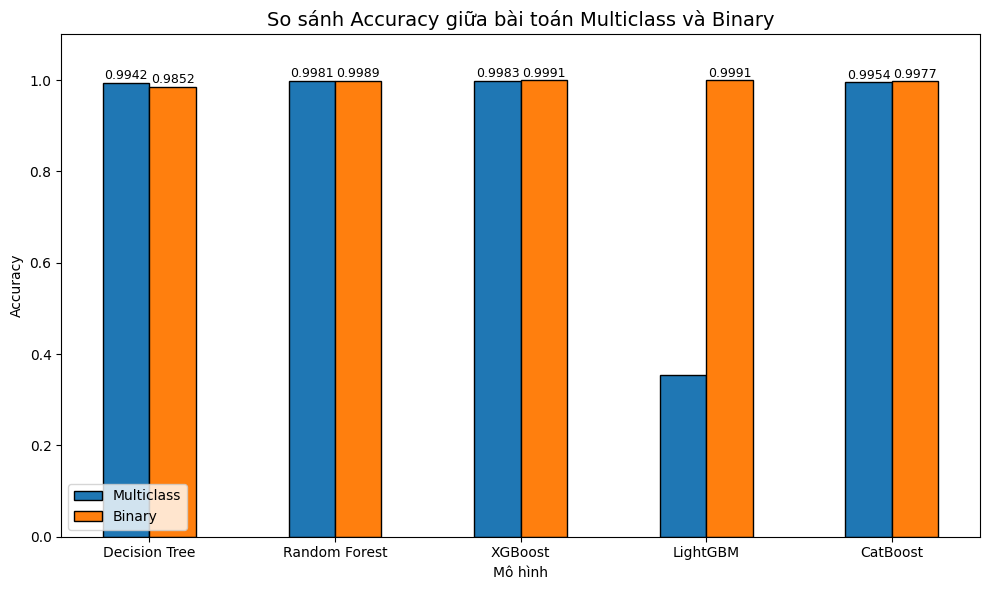

In [64]:
#Mô hình trực quan 

models = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
multiclass_acc = [0.9942,0.9981,0.9983,0.3544,0.9954]
binary_acc = [0.9852,0.9989,0.9991,0.9991,0.9977]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, multiclass_acc, width, label='Multiclass', edgecolor='black')
bars2 = plt.bar(x + width/2, binary_acc, width, label='Binary', edgecolor='black')

plt.title('So sánh Accuracy giữa bài toán Multiclass và Binary', fontsize=14)
plt.xlabel('Mô hình')
plt.ylabel('Accuracy')
plt.xticks(x, models, rotation=0)
plt.legend()
plt.ylim(0.0, 1.10)

for bars in [bars1, bars2]:
    for bar in bars:
        y = bar.get_height()
        if y <= 0.5:
            continue
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y + 0.001,
            f'{y:.4f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()



In [65]:
# Cell 1: Hàm tính TPR/FPR
def calc_tpr_fpr(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    tpr_list = []
    fpr_list = []
    total = cm.sum()
    
    for i in range(len(labels)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP
        
        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    
    return pd.DataFrame({
        'Label': labels,
        'TPR': tpr_list,
        'FPR': fpr_list
    })

In [66]:
# Cell 2: Tính scores Multiclass
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Danh sách nhãn multiclass — SỬA LẠI theo nhãn thực tế
labels_multi = ['BENIGN', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'PortScan', 'WebAttack']

scores_multi = {}

for model_name, y_pred in [
    ('Decision Tree', y_pred_dt_m),
    ('Random Forest', y_pred_rf_m),
    ('XGBoost',       y_pred_xgb_m),
    ('LightGBM',      y_pred_lgbm_m),
    ('CatBoost',      y_pred_cat_m)
]:
    scores_multi[model_name] = {
        'Accuracy':  accuracy_score(y_test_m, y_pred),
        'Precision': precision_score(y_test_m, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test_m, y_pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_test_m, y_pred, average='weighted', zero_division=0)
    }

print("Scores Multiclass đã tính xong!")

Scores Multiclass đã tính xong!


In [67]:
# Cell 3: Tính scores Binary
scores_binary = {}

for model_name, y_pred in [
    ('Decision Tree',    y_pred_dt_b),
    ('Random Forest',    y_pred_rf_b),
    ('XGBoost',          y_pred_xgb_b),
    ('LightGBM',         y_pred_lgbm_b),
    ('CatBoost',         y_pred_cat_b)
]:
    scores_binary[model_name] = {
        'Accuracy':  accuracy_score(y_test_b, y_pred),
        'Precision': precision_score(y_test_b, y_pred, zero_division=0),
        'Recall':    recall_score(y_test_b, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_test_b, y_pred, zero_division=0)
    }

print("Scores Binary đã tính xong!")

Scores Binary đã tính xong!


        Label  Decision Tree  Random Forest   XGBoost  LightGBM  CatBoost
0      BENIGN       0.993993       0.998407  0.998640  0.277653  0.995980
1         Bot       0.928450       0.947189  0.976150  0.448041  0.945486
2  BruteForce       0.928944       0.961538  0.945458  0.233377  0.897436
3        DDoS       0.997891       0.999531  0.999818  0.303348  0.998412
4         DoS       0.994849       0.999470  0.999828  0.137937  0.996994
5    PortScan       0.998867       0.999811  0.999769  0.992318  0.998909
6   WebAttack       0.806931       0.579208  0.732673  0.034653  0.935644


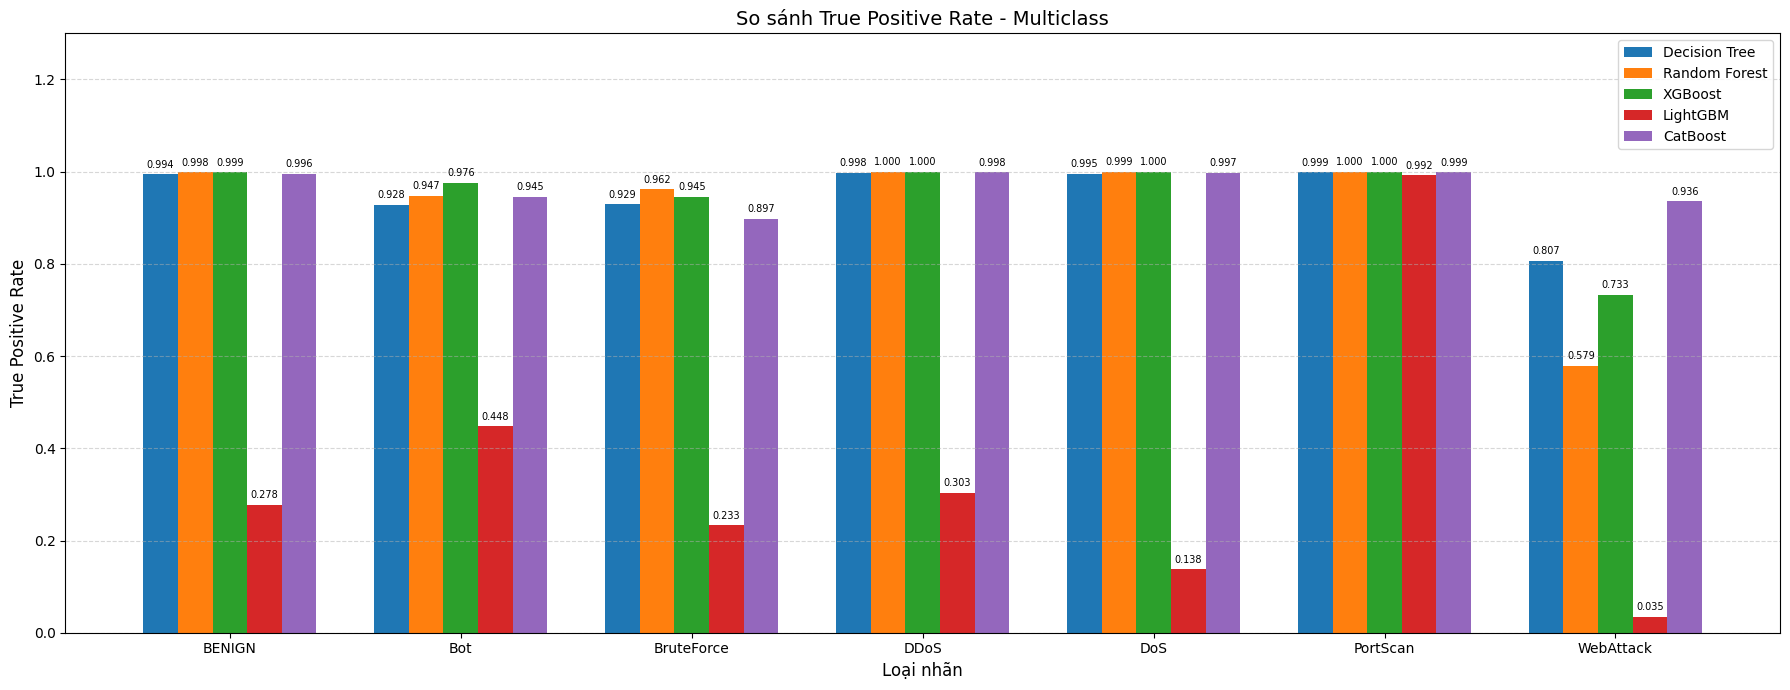

In [68]:
# Cell 4: Vẽ TPR Multiclass
dt_metrics_m   = calc_tpr_fpr(y_test_m, y_pred_dt_m,   labels_multi)
rf_metrics_m   = calc_tpr_fpr(y_test_m, y_pred_rf_m,   labels_multi)
xgb_metrics_m  = calc_tpr_fpr(y_test_m, y_pred_xgb_m,  labels_multi)
lgbm_metrics_m = calc_tpr_fpr(y_test_m, y_pred_lgbm_m, labels_multi)
cat_metrics_m  = calc_tpr_fpr(y_test_m, y_pred_cat_m,  labels_multi)

tpr_df_m = pd.DataFrame({
    'Label':         labels_multi,
    'Decision Tree': dt_metrics_m['TPR'].values,
    'Random Forest': rf_metrics_m['TPR'].values,
    'XGBoost':       xgb_metrics_m['TPR'].values,
    'LightGBM':      lgbm_metrics_m['TPR'].values,
    'CatBoost':      cat_metrics_m['TPR'].values
})

print(tpr_df_m)

plt.figure(figsize=(18, 7))
x = np.arange(len(labels_multi))
width = 0.15

bars1 = plt.bar(x - 2*width, tpr_df_m['Decision Tree'], width, label='Decision Tree')
bars2 = plt.bar(x - 1*width, tpr_df_m['Random Forest'], width, label='Random Forest')
bars3 = plt.bar(x + 0*width, tpr_df_m['XGBoost'],       width, label='XGBoost')
bars4 = plt.bar(x + 1*width, tpr_df_m['LightGBM'],      width, label='LightGBM')
bars5 = plt.bar(x + 2*width, tpr_df_m['CatBoost'],      width, label='CatBoost')

plt.title('So sánh True Positive Rate - Multiclass', fontsize=14)
plt.xlabel('Loại nhãn', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.xticks(x, labels_multi, ha='center')
plt.ylim(0, 1.3)
plt.legend(fontsize=10, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y + 0.01,
            f'{y:.3f}',
            ha='center', va='bottom', fontsize=7
        )

plt.tight_layout()
plt.show()

    Label  Decision Tree  Random Forest   XGBoost  LightGBM  CatBoost
0  Benign       0.971400       0.998347  0.998453   0.99850  0.996247
1  Attack       0.997664       0.999401  0.999701   0.99973  0.998976


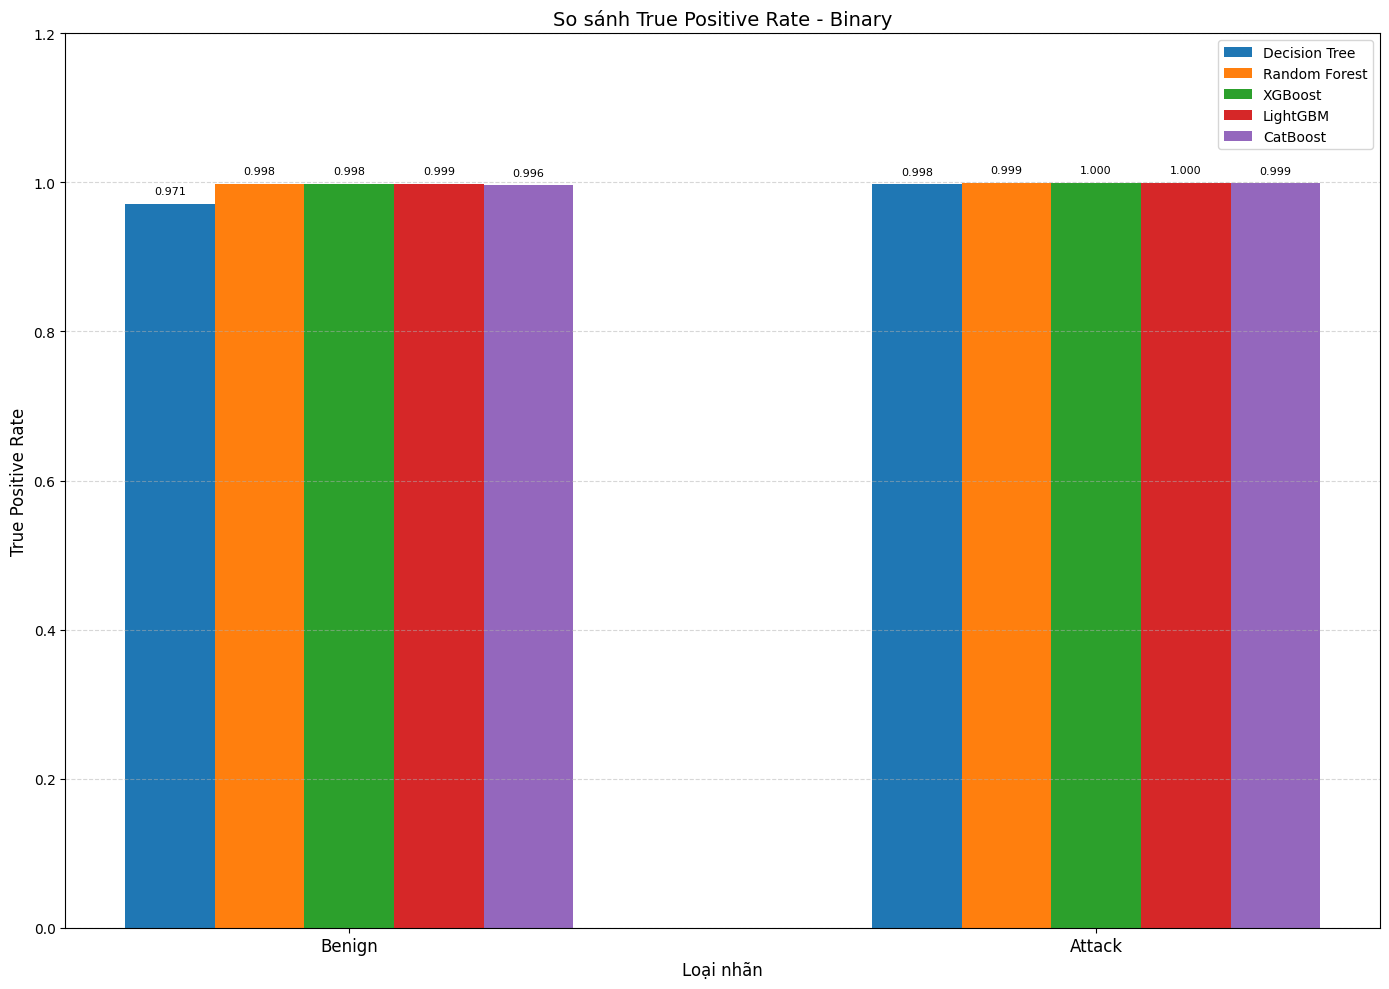

In [69]:
# Cell 5: Vẽ TPR Binary
labels_binary = [0, 1]

dt_metrics_b   = calc_tpr_fpr(y_test_b, y_pred_dt_b,   labels_binary)
rf_metrics_b   = calc_tpr_fpr(y_test_b, y_pred_rf_b,   labels_binary)
xgb_metrics_b  = calc_tpr_fpr(y_test_b, y_pred_xgb_b,  labels_binary)
lgbm_metrics_b = calc_tpr_fpr(y_test_b, y_pred_lgbm_b, labels_binary)
cat_metrics_b  = calc_tpr_fpr(y_test_b, y_pred_cat_b,  labels_binary)

tpr_df_b = pd.DataFrame({
    'Label':            ['Benign', 'Attack'],
    'Decision Tree':    dt_metrics_b['TPR'].values,
    'Random Forest':    rf_metrics_b['TPR'].values,
    'XGBoost':          xgb_metrics_b['TPR'].values,
    'LightGBM':         lgbm_metrics_b['TPR'].values,
    'CatBoost':         cat_metrics_b['TPR'].values
})

print(tpr_df_b)

plt.figure(figsize=(14, 10))
x = np.arange(2)
width = 0.12

bars1 = plt.bar(x - 2*width, tpr_df_b['Decision Tree'],    width, label='Decision Tree')
bars2 = plt.bar(x - 1*width, tpr_df_b['Random Forest'],    width, label='Random Forest')
bars3 = plt.bar(x - 0*width, tpr_df_b['XGBoost'],          width, label='XGBoost')
bars4 = plt.bar(x + 1*width, tpr_df_b['LightGBM'],         width, label='LightGBM')
bars5 = plt.bar(x + 2*width, tpr_df_b['CatBoost'],         width, label='CatBoost')

plt.title('So sánh True Positive Rate - Binary', fontsize=14)
plt.xlabel('Loại nhãn', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.xticks(x, ['Benign', 'Attack'], fontsize=12)
plt.ylim(0, 1.2)
plt.legend(fontsize=10, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y + 0.01,
            f'{y:.3f}',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

In [70]:
# Cell 6: Bảng so sánh tổng hợp
print("BẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ (MULTICLASS)")
print("=" * 60)
df_multi = pd.DataFrame(scores_multi).transpose().round(4)
df_multi.index.name = 'Mô hình'
print(df_multi.to_string())

print("\nBẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ (BINARY)")
print("=" * 60)
df_binary = pd.DataFrame(scores_binary).transpose().round(4)
df_binary.index.name = 'Mô hình'
print(df_binary.to_string())

BẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ (MULTICLASS)
               Accuracy  Precision  Recall  F1-Score
Mô hình                                             
Decision Tree    0.9942     0.9948  0.9942    0.9944
Random Forest    0.9981     0.9983  0.9981    0.9982
XGBoost          0.9983     0.9986  0.9983    0.9984
LightGBM         0.3544     0.5174  0.3544    0.3645
CatBoost         0.9954     0.9962  0.9954    0.9957

BẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ (BINARY)
               Accuracy  Precision  Recall  F1-Score
Mô hình                                             
Decision Tree    0.9852     0.9749  0.9977    0.9861
Random Forest    0.9989     0.9985  0.9994    0.9990
XGBoost          0.9991     0.9986  0.9997    0.9992
LightGBM         0.9991     0.9987  0.9997    0.9992
CatBoost         0.9977     0.9966  0.9990    0.9978


# Xong